## **Classificação:**
### Probabilidade de classificação do gráfico 

* A probabilidade de classificação é a chance (de 0% a 100%) de algo ou alguém alcançar uma meta ou entrar para um grupo específico em uma tabela ou gráfico, com base em dados atuais e estatísticas.

In [ ]:
%pip install scikit-learn

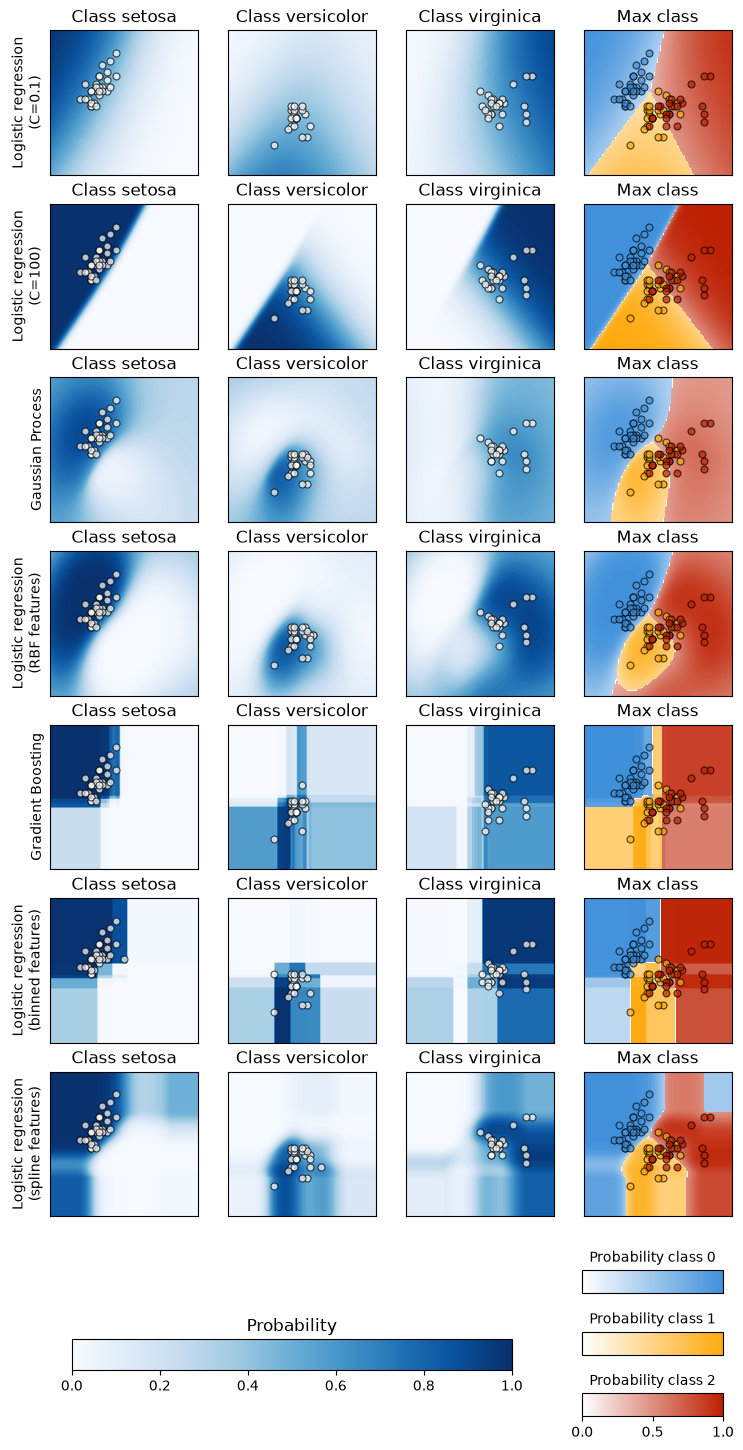

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

from sklearn import datasets
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer,
    PolynomialFeatures,
    SplineTransformer,
)

iris = datasets.load_iris()
X = iris.data[:, 0:2]  # we only take the first two features for visualization
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

classifiers = {
    "Logistic regression\n(C=0.1)": LogisticRegression(C=0.1),
    "Logistic regression\n(C=100)": LogisticRegression(C=100),
    "Gaussian Process": GaussianProcessClassifier(kernel=1.0 * RBF([1.0, 1.0])),
    "Logistic regression\n(RBF features)": make_pipeline(
        Nystroem(kernel="rbf", gamma=5e-1, n_components=50, random_state=1),
        LogisticRegression(C=10),
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "Logistic regression\n(binned features)": make_pipeline(
        KBinsDiscretizer(n_bins=5, quantile_method="averaged_inverted_cdf"),
        PolynomialFeatures(interaction_only=True),
        LogisticRegression(C=10),
    ),
    "Logistic regression\n(spline features)": make_pipeline(
        SplineTransformer(n_knots=5),
        PolynomialFeatures(interaction_only=True),
        LogisticRegression(C=10),
    ),
}

n_classifiers = len(classifiers)
scatter_kwargs = {
    "s": 25,
    "marker": "o",
    "linewidths": 0.8,
    "edgecolor": "k",
    "alpha": 0.7,
}
y_unique = np.unique(y)

# Ensure legend not cut off
mpl.rcParams["savefig.bbox"] = "tight"
fig, axes = plt.subplots(
    nrows=n_classifiers,
    ncols=len(iris.target_names) + 1,
    figsize=(4 * 2.2, n_classifiers * 2.2),
)
evaluation_results = []
levels = 100
for classifier_idx, (name, classifier) in enumerate(classifiers.items()):
    y_pred = classifier.fit(X_train, y_train).predict(X_test)
    y_pred_proba = classifier.predict_proba(X_test)
    accuracy_test = accuracy_score(y_test, y_pred)
    roc_auc_test = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")
    log_loss_test = log_loss(y_test, y_pred_proba)
    evaluation_results.append(
        {
            "name": name.replace("\n", " "),
            "accuracy": accuracy_test,
            "roc_auc": roc_auc_test,
            "log_loss": log_loss_test,
        }
    )
    for label in y_unique:
        # plot the probability estimate provided by the classifier
        disp = DecisionBoundaryDisplay.from_estimator(
            classifier,
            X_train,
            response_method="predict_proba",
            class_of_interest=label,
            ax=axes[classifier_idx, label],
            vmin=0,
            vmax=1,
            cmap="Blues",
            levels=levels,
        )
        axes[classifier_idx, label].set_title(f"Class {iris.target_names[label]}")
        # plot data predicted to belong to given class
        mask_y_pred = y_pred == label
        axes[classifier_idx, label].scatter(
            X_test[mask_y_pred, 0], X_test[mask_y_pred, 1], c="w", **scatter_kwargs
        )

        axes[classifier_idx, label].set(xticks=(), yticks=())
    # add column that shows all classes by plotting class with max 'predict_proba'
    max_class_disp = DecisionBoundaryDisplay.from_estimator(
        classifier,
        X_train,
        response_method="predict_proba",
        class_of_interest=None,
        ax=axes[classifier_idx, len(y_unique)],
        vmin=0,
        vmax=1,
        levels=levels,
    )
    for label in y_unique:
        mask_label = y_test == label
        max_col = len(y_unique)
        axes[classifier_idx, max_col].scatter(
            X_test[mask_label, 0],
            X_test[mask_label, 1],
            c=max_class_disp.multiclass_colors_[[label], :],
            **scatter_kwargs,
        )

    axes[classifier_idx, 3].set(xticks=(), yticks=())
    axes[classifier_idx, 3].set_title("Max class")
    axes[classifier_idx, 0].set_ylabel(name)

# colorbar for single class plots
ax_single = fig.add_axes([0.15, 0.01, 0.5, 0.02])
plt.title("Probability")
_ = plt.colorbar(
    cm.ScalarMappable(norm=None, cmap=disp.surface_.cmap),
    cax=ax_single,
    orientation="horizontal",
)

# colorbars for max probability class column
max_class_cmaps = [s.cmap for s in max_class_disp.surface_]

for label in y_unique:
    ax_max = fig.add_axes([0.73, (0.06 - (label * 0.04)), 0.16, 0.015])
    plt.title(f"Probability class {label}", fontsize=10)
    _ = plt.colorbar(
        cm.ScalarMappable(norm=None, cmap=max_class_cmaps[label]),
        cax=ax_max,
        orientation="horizontal",
    )
    if label in (0, 1):
        ax_max.set(xticks=(), yticks=())

# **Regressão:** 
## Destaques da versão -.23 do scikit-learn

### • **Exibição em HTML:** Gráficos interativos para pipelines no Jupyter Notebook.
### • **Novos Modelos (GLMs):** Regressores baseados em Poisson, Gamma e Tweedie.
### • **KMeans Melhorado:** Algoritmo mais rápido, estável e com melhor suporte a dados esparsos.
### • **Histogram Gradient Boosting:** Suporte a restrições monotônicas e perda de Poisson.
### • **Argumentos Nominais:** Obrigatoriedade de nomear parâmetros para evitar erros no código.


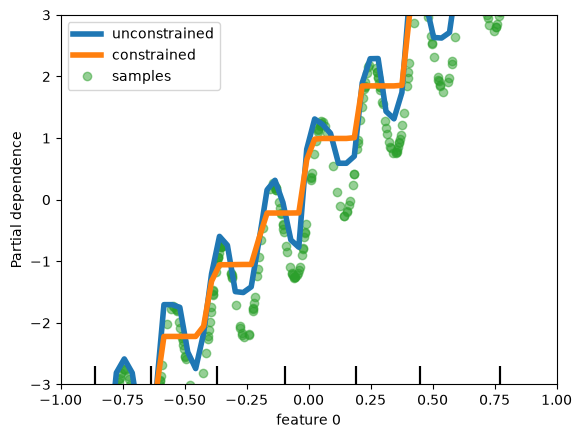

In [3]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor

# from sklearn.inspection import plot_partial_dependence
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

n_samples = 500
rng = np.random.RandomState(0)
X = rng.randn(n_samples, 2)
noise = rng.normal(loc=0.0, scale=0.01, size=n_samples)
y = 5 * X[:, 0] + np.sin(10 * np.pi * X[:, 0]) - noise

gbdt_no_cst = HistGradientBoostingRegressor().fit(X, y)
gbdt_cst = HistGradientBoostingRegressor(monotonic_cst=[1, 0]).fit(X, y)

# plot_partial_dependence has been removed in version 1.2. From 1.2, use
# PartialDependenceDisplay instead.
# disp = plot_partial_dependence(
disp = PartialDependenceDisplay.from_estimator(
    gbdt_no_cst,
    X,
    features=[0],
    feature_names=["feature 0"],
    line_kw={"linewidth": 4, "label": "unconstrained", "color": "tab:blue"},
)
# plot_partial_dependence(
PartialDependenceDisplay.from_estimator(
    gbdt_cst,
    X,
    features=[0],
    line_kw={"linewidth": 4, "label": "constrained", "color": "tab:orange"},
    ax=disp.axes_,
)
disp.axes_[0, 0].plot(
    X[:, 0], y, "o", alpha=0.5, zorder=-1, label="samples", color="tab:green"
)
disp.axes_[0, 0].set_ylim(-3, 3)
disp.axes_[0, 0].set_xlim(-1, 1)
plt.legend()
plt.show()